In [ ]:
import matplotlib.pyplot as plt
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    XXPlusYYGate,
    iSwapGate,
    XGate,
    IGate,
    YGate,
    ZGate,
    RVGate,
)
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import trange

from gulps import logger
from gulps.core.coverage import coverage_report
from gulps.core.invariants import GateInvariants
from gulps.core.isa import DiscreteISA
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import plot_decomposition
from qiskit import QuantumCircuit
from gulps.viz.report_viz import report_benchmark_results
from gulps.isa_library.fsim import fsim
import numpy as np

Extensions of symmetric operators. Finding self-adjoint extensions, with various requirements, of symmetric operators is equivalent to finding unitary extensions of suitable partial isometries.

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

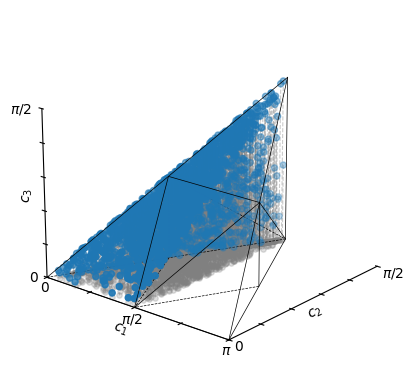

In [36]:
X = XGate().power(1.0).to_matrix()
V = IGate().to_matrix()  # Just an example, replace with any 2x2 unitary

U_list = []
for _ in range(2000):
    V = random_unitary(2)
    U = np.zeros((4, 4), dtype=complex)

    # Put X on the {|01>,|10>} subspace (indices 1 and 2 in |00>,|01>,|10>,|11|)
    U[np.ix_([1, 2], [1, 2])] = X

    # Put V on the {|00>,|11>} subspace (indices 0 and 3)
    U[np.ix_([0, 3], [0, 3])] = V
    U_list.append(GateInvariants.from_unitary(U))

# GateInvariants.from_unitary(U).plot()
from gulps.viz.invariant_viz import scatter_plot

scatter_plot(U_list)

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

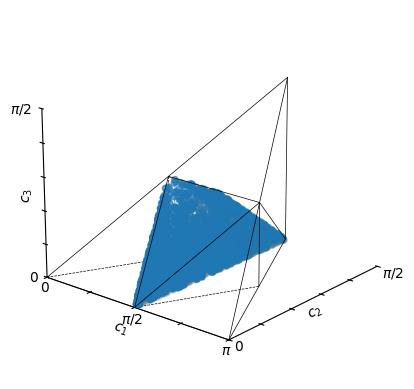

In [ ]:
X = XGate().power(1 / 2).to_matrix()
V = IGate().to_matrix()  # Just an example, replace with any 2x2 unitary

U_list = []
for _ in range(2000):
    V = random_unitary(2)
    U = np.zeros((4, 4), dtype=complex)

    # Put X on the {|01>,|10>} subspace (indices 1 and 2 in |00>,|01>,|10>,|11|)
    U[np.ix_([1, 2], [1, 2])] = X

    # Put V on the {|00>,|11>} subspace (indices 0 and 3)
    U[np.ix_([0, 3], [0, 3])] = V
    U_list.append(GateInvariants.from_unitary(U))

# GateInvariants.from_unitary(U).plot()
from gulps.viz.invariant_viz import scatter_plot

scatter_plot(U_list)

In [89]:
from scipy.optimize import minimize
from qiskit.circuit.library import U3Gate
import qutip as qt

target_inv = GateInvariants.from_weyl((0.5, 0.0, 0.0))
logical_op = XGate().power(1 / 2).to_matrix()


def cost(params):
    U = ansatz(params)
    inv = GateInvariants.from_unitary(U)
    return np.linalg.norm(np.array(inv.makhlin) - np.array(target_inv.makhlin))


def ansatz(params):
    # V = random_unitary(2)
    V = RVGate(params[0], params[1], params[2]).to_matrix()
    U = np.zeros((4, 4), dtype=complex)
    U[np.ix_([1, 2], [1, 2])] = logical_op
    U[np.ix_([0, 3], [0, 3])] = V
    return U


res = minimize(cost, x0=np.random.rand(3), method="Nelder-Mead")
V = RVGate(res.x[0], res.x[1], res.x[2]).to_matrix()
V

array([[ 0.70299947-0.075855j  , -0.14421687-0.69227109j],
       [ 0.14421687-0.69227109j,  0.70299947+0.075855j  ]])

In [90]:
U = np.zeros((4, 4), dtype=complex)

# Put X on the {|01>,|10>} subspace (indices 1 and 2 in |00>,|01>,|10>,|11|)
U[np.ix_([1, 2], [1, 2])] = X

# Put V on the {|00>,|11>} subspace (indices 0 and 3)
U[np.ix_([0, 3], [0, 3])] = V
qt.Qobj(U)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.70299947-0.075855j    0.        +0.j          0.        +0.j
  -0.14421687-0.69227109j]
 [ 0.        +0.j          0.5       +0.5j         0.5       -0.5j
   0.        +0.j        ]
 [ 0.        +0.j          0.5       -0.5j         0.5       +0.5j
   0.        +0.j        ]
 [ 0.14421687-0.69227109j  0.        +0.j          0.        +0.j
   0.70299947+0.075855j  ]]